# Clasificador Naive Bayes

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [4]:
data = sns.load_dataset('iris')
train, test = train_test_split(data, test_size=0.4, stratify=data['species'], random_state=23)

In [5]:
# Separación de la etiqueta de clase y atributos
X_train = train[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y_train = train['species']

X_test = test[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y_test = test['species']

In [6]:
mod_gnb = GaussianNB()
mod_gnb.fit(X_train, y_train)
prediccion = mod_gnb.predict(X_test)

In [8]:
eficiencia = metrics.accuracy_score(prediccion, y_test)
print('Eficiencia del modelo: ', f'{eficiencia:0.2f}')

Eficiencia del modelo:  0.97


In [10]:
test['y_pred'] = prediccion
test.head()

,sepal_length,sepal_width,petal_length,petal_width,species,y_pred
26,5.0,3.4,1.6,0.4,setosa,setosa
142,5.8,2.7,5.1,1.9,virginica,virginica
68,6.2,2.2,4.5,1.5,versicolor,versicolor
64,5.6,2.9,3.6,1.3,versicolor,versicolor
37,4.9,3.6,1.4,0.1,setosa,setosa


In [12]:
print(metrics.classification_report(y_test, prediccion))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        20
  versicolor       0.91      1.00      0.95        20
   virginica       1.00      0.90      0.95        20

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



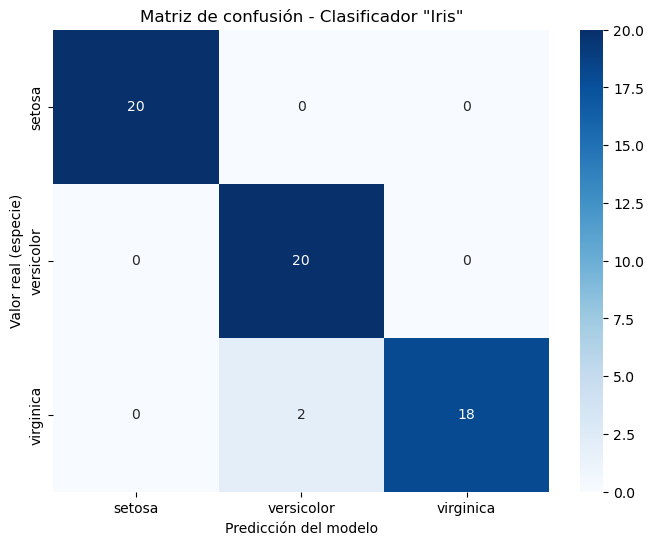

In [14]:
cm = metrics.confusion_matrix(y_test, prediccion)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=mod_gnb.classes_, yticklabels=mod_gnb.classes_)
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real (especie)')
plt.title('Matriz de confusión - Clasificador "Iris"')
plt.show()